# Loading Data

In [1]:
import pandas as pd

train_df = pd.read_csv(r"../data/preprocessed/train_df.csv")

train_df.head()

,T50_mean_residual,T48_mean_residual,T40_mean_residual,phi_mean_residual,SmLPC_mean_residual,SmHPC_mean_residual,Ps30_mean_residual,P15_mean_residual,unit,cycle,RUL,Fc_2.0,Fc_3.0
0,-5.416630,-5.632471,-5.230940,-0.151049,0.259604,0.195312,1.727576,0.077789,1.0,1.0,99,0.0,0.0
1,-5.984193,-6.631862,-6.509046,-0.184754,0.234574,0.211266,-0.109391,-0.025317,1.0,2.0,98,0.0,0.0
2,-4.357649,-4.098077,-2.889798,-0.124389,0.169070,0.183519,0.703531,0.083900,1.0,3.0,97,0.0,0.0
3,-5.705199,-9.856065,-11.678185,-0.271159,0.271064,0.280815,0.405351,0.086737,1.0,4.0,96,0.0,0.0
4,-5.563820,-7.811484,-8.632152,-0.230184,0.153258,0.234353,-1.054312,-0.036495,1.0,5.0,95,0.0,0.0


In [2]:
train_df.shape

(553, 13)

In [3]:
type(train_df['unit'])

pandas.Series

In [4]:
train_df.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual', 'unit', 'cycle', 'RUL',
       'Fc_2.0', 'Fc_3.0'],
      dtype='str')

In [5]:
print(train_df[train_df["unit"] == 1].shape)
print(train_df[train_df["unit"] == 3].shape)

print(train_df[train_df["unit"] == 1]["RUL"].values[:5])
print(train_df[train_df["unit"] == 3]["RUL"].values[:5])

(100, 13)
(100, 13)
[99 98 97 96 95]
[99 98 97 96 95]


## Validation and testing

- using LOUO-CV 
- delete unit , cycle from training to prevent Data Leackage

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


rmse_score = []


for unit in range(1, 7):    
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    train_data = train_df[train_df["unit"] != unit]
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # training model
    model = LinearRegression()
    model.fit(x_train, y_train)
    predicts = model.predict(x_val)
    rmse_score.append(np.sqrt(mean_squared_error(y_val, predicts)))
    
    

The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213
The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658


In [7]:
rmse_score

[np.float64(17.11905312992984),
 np.float64(16.047616599540593),
 np.float64(21.40684476037862),
 np.float64(15.616765421674378),
 np.float64(15.733035765258103),
 np.float64(14.54764913091934)]

In [8]:
naive_rmse_score = []

for unit in range(1, 7):    
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    train_data = train_df[train_df["unit"] != unit]
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # Naive Baseline
    naive_prediction = y_train.mean()
    
    naive_predictions = [naive_prediction] * len(y_val)
    
    naive_rmse_score.append(np.sqrt(mean_squared_error(y_val, naive_predictions)))

print("Naive Scores : \n", naive_rmse_score)

The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213
The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658
Naive Scores : 
 [np.float64(29.18412978289386), np.float64(24.01250734224367), np.float64(29.18412978289386), np.float64(27.4502540435382), np.float64(25.798627736972364), np.float64(27.141155629851568)]


# PHM08 Score

- d = RUL_predicted - RUL_actual
- > s_i = exponential(-d / 13) - 1 if d < 0 (Early predict)
- > s_i = exponential(d / 10) -1 if d >= 0 (late predict)
- > score = summition(s_i)

In [9]:
def phm08(y_pred, y_actual):
    d = y_pred - y_actual
    s_i = 0
    
    for element in d:
        if element < 0 : 
            s_i += np.exp(-element / 13) -1

        else:
            s_i += np.exp(element / 10) -1

    return s_i

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


rmse_score = []
phm08_score = []

for unit in range(1, 7):    
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    train_data = train_df[train_df["unit"] != unit]
    
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # training model
    model = LinearRegression()
    model.fit(x_train, y_train)
    predicts = model.predict(x_val)
    rmse_score.append(np.sqrt(mean_squared_error(y_val, predicts)))
    phm08_score.append(phm08(predicts, y_val.values))
    
print("Scores of mean Square Error : \n", rmse_score)
print("Scores of PHM08 score : \n", phm08_score)


The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213
The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658
Scores of mean Square Error : 
 [np.float64(17.11905312992984), np.float64(16.047616599540593), np.float64(21.40684476037862), np.float64(15.616765421674378), np.float64(15.733035765258103), np.float64(14.54764913091934)]
Scores of PHM08 score : 
 [np.float64(351.3280237826836), np.float64(298.60970043727514), np.float64(727.3694799767832), np.float64(309.98472482046805), np.float64(246.32529921416355), np.float64(224.86471525075493)]


## Baseline Model Summary

**Model:** Linear Regression on 8 residual-corrected sensor features
**Validation Strategy:** Leave-One-Unit-Out Cross-Validation (LOUO-CV) across 6 engine units

### Results by Fold

| Unit (validation) | RMSE | PHM08 Score |
|---|---|---|
| 1 | 17.49 | 361.36 |
| 2 | 16.08 | 301.79 |
| 3 | **21.00** | **652.75** |
| 4 | 15.44 | 276.60 |
| 5 | 13.62 | 200.29 |
| 6 | 14.30 | 220.87 |
| **Average / Total** | **16.32** | **2013.68** |

### Naive Baseline Comparison
A constant-mean predictor (predicting the training mean RUL regardless of input) scored an average RMSE of **27.13** across the same folds — the trained model (16.32) clearly outperforms it, confirming the residual features carry real predictive signal rather than the model just learning the average.

### Observations
- **Unit 3 is consistently the hardest to predict** across both metrics (highest RMSE and highest PHM08 score, roughly 2x the next-worst fold on PHM08). This is flagged for follow-up investigation, not yet root-caused.
- The wide gap between RMSE (~16 cycles) and PHM08 score magnitude (~2000 total) reflects the exponential penalty structure of PHM08 — a reminder that RMSE and PHM08 answer different questions (average error vs. asymmetric risk of late predictions).

### Status
This is the **official baseline** for the project. Any subsequent model (e.g., tree-based models, added features) must be compared against these numbers using the same LOUO-CV protocol to be considered an improvement.

### Experiment Log

**Experiment 1 — Adding `Fc` (flight class) as a categorical feature**
`Fc` was one-hot encoded (`Fc_2.0`, `Fc_3.0`, with `Fc=1.0` as reference) and added to the 8 baseline features, using the same LOUO-CV protocol.

| Metric | Baseline (8 features) | + Fc (10 features) | Result |
|---|---|---|---|
| RMSE (avg) | 16.32 | 16.75 | ❌ Worse |
| PHM08 (total) | 2013.68 | 2158.48 | ❌ Worse |

**Conclusion:** `Fc` did not improve performance — it slightly degraded both metrics, likely due to added model complexity relative to the small dataset size (553 rows) increasing the risk of mild overfitting without a corresponding gain in signal. **`Fc` is excluded from the official feature set.** The 8 residual-corrected sensors remain the baseline.

- Deleting FC columns

In [11]:
train_df.drop(columns=["Fc_2.0", "Fc_3.0"], inplace=True)

In [12]:
train_df.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual', 'unit', 'cycle', 'RUL'],
      dtype='str')

In [13]:
from sklearn.ensemble import RandomForestRegressor

rmse_score = []
phm08_score = []

for unit in range(1, 7): 
    # Creating validation set   
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    # Creating training set
    train_data = train_df[train_df["unit"] != unit]
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # training model
    model = RandomForestRegressor(random_state=42)
    model.fit(x_train, y_train)
    predicts = model.predict(x_val)
    rmse_score.append(np.sqrt(mean_squared_error(y_val, predicts)))
    phm08_score.append(phm08(predicts, y_val.values))
    
print("Scores of mean Square Error : \n", rmse_score)
print("Scores of PHM08 score : \n", phm08_score)


The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213
The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658
Scores of mean Square Error : 
 [np.float64(10.089768976542526), np.float64(15.442459605473044), np.float64(15.047305871816393), np.float64(9.532794144977972), np.float64(9.345152802328938), np.float64(10.264116123039239)]
Scores of PHM08 score : 
 [np.float64(118.92920077201453), np.float64(347.5271004500233), np.float64(264.3297547584272), np.float64(137.97412614711587), np.float64(91.4597128724895), np.float64(159.8025259288993)]


### Compare between Random Forest and Linear Regression by Fold

| metric | Linear Regression | Random Forest | Improvement |
|---|---|---|---|
| Mean of RMSE | 16.32 | 11.59 | improving by 29% |
| Summition of PHM08 | 2013.68 | 1087.7 | improving by 46% |



### Fold Details
| Unit | RF RMSE | RF PHM08 | LR RMSE (for comparing) |
|---|---|---|---|
| 1 | 10.31 | 122.50 | 17.49 |
| 2 | 15.15 | 331.44 | 16.08 | 
| **3** | **14.97** | **259.31** | **21.00** |
| 4 | 9.67 | 140.41 | 15.44 |
| 5 | 9.42 | 93.02 | 13.62 |
| 6 | 10.03 | 141.03 | 14.30 |


### Trying XGBoost model 
- using xgboost with With restricted settings because small amount of data (500)

In [14]:
from xgboost import XGBRegressor


rmse_score = []
phm08_score = []

for unit in range(1, 7): 
    # Creating validation set   
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    # Creating training set
    train_data = train_df[train_df["unit"] != unit]
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # training model
    model = XGBRegressor(random_state=42)
    
    model.fit(x_train, y_train)
    predicts = model.predict(x_val)
    rmse_score.append(np.sqrt(mean_squared_error(y_val, predicts)))
    phm08_score.append(phm08(predicts, y_val.values))
    
print("Scores of mean Square Error : \n", rmse_score)
print("Scores of PHM08 score : \n", phm08_score)


The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213
The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658
Scores of mean Square Error : 
 [np.float64(10.687733430153628), np.float64(16.006010833824273), np.float64(16.17778707604147), np.float64(10.027383314588873), np.float64(10.51805778125154), np.float64(10.04786746045795)]
Scores of PHM08 score : 
 [np.float64(125.39321317003898), np.float64(402.1667893754867), np.float64(325.23913386388386), np.float64(151.7074449267884), np.float64(116.20469620420629), np.float64(161.50776221604275)]


- using xgboost with With restricted settings because small amount of data (500)

In [15]:
rmse_score = []
phm08_score = []

for unit in range(1, 7): 
    # Creating validation set   
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    # Creating training set
    train_data = train_df[train_df["unit"] != unit]
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # training model
    model = XGBRegressor(
        max_depth=3, 
        learning_rate=0.05,
        n_estimators=300,
        random_state=42,
    )
    
    model.fit(x_train, y_train)
    predicts = model.predict(x_val)
    rmse_score.append(np.sqrt(mean_squared_error(y_val, predicts)))
    phm08_score.append(phm08(predicts, y_val.values))
    
print("Scores of mean Square Error : \n", rmse_score)
print("Scores of PHM08 score : \n", phm08_score)


The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213
The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658
Scores of mean Square Error : 
 [np.float64(9.872789352786384), np.float64(15.178194185585832), np.float64(15.071980512116422), np.float64(9.13502474342507), np.float64(10.070626904275482), np.float64(8.96005454864246)]
Scores of PHM08 score : 
 [np.float64(111.2760350036788), np.float64(332.09922845179796), np.float64(263.10237841483485), np.float64(126.18018378830503), np.float64(108.94110536780447), np.float64(133.1049732362396)]


### Compare between Random Forest, Linear Regression and XGBoost by Fold

| metric | Linear Regression | Random Forest | XGBoost(default) | XGBoost(restricted settings) |
|---|---|---|---|---|
| Mean of RMSE | 16.32 | 11.62 | 12.24 | 11.38 |
| Summition of PHM08 | 2013.68 | 1120.0 | 1282.2 | 1074.7 |



### Fold Details
| Unit | RF | restricted XGB | difference |
|---|---|---|---|
| 1 | 10.09 | 9.87 | Better✅ |
| 2 | 15.44 | 15.18 | Better✅ | 
| 3 | **15.05** | **15.07** | **Draw≈** |
| 4 | 9.53 | 9.13 | Better✅ |
| 5 | 9.35 | 10.07 | Worse❌ |
| 6 | 10.26 | 8.96 | Better✅ |


**5 out of the 6 folds improved or stayed the same — a consistent pattern shows the improvement is real, not just a fluke in one fold.**

## ✅ The official final ranking of the project :
1. naive Baseline: RMSE ≈ 27.13
2. Linear Regression: RMSE ≈ 16.32
3. Random Forest: RMSE ≈ 11.62
4. XGBoost (Tuned): RMSE ≈ 11.38 ← 🏆Better for now

## Fine Tunning XGBoost model

In [16]:
from sklearn.model_selection import RandomizedSearchCV, LeaveOneGroupOut
from xgboost import XGBRegressor

X_train = train_df.drop(columns=["unit", "cycle", "RUL"])
y_train = train_df["RUL"]
groups = train_df["unit"]

params_grid = {
    "max_depth" : [2, 3, 4, 5],
    "learning_rate" : [0.001, 0.01, 0.03, 0.05, 0.1],
    "n_estimators" : [100, 200, 250, 300, 350, 400, 500],
    "subsample" : [0.5, 0.7, 0.8, 1.0],
}

model = XGBRegressor(random_state=42)
LOGO = LeaveOneGroupOut()


Searcher = RandomizedSearchCV(
    estimator=model,
    param_distributions=params_grid,
    cv=LOGO,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    random_state=42
)

Searcher.fit(X_train, y_train, groups=groups)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.001, 0.01, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.5, 0.7, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneGroupOut()
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``R

In [17]:
Searcher.best_params_

{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.1}

In [18]:
Searcher.best_score_

np.float64(-11.186676502227783)

In [19]:
rmse_score = []
phm08_score = []

for unit in range(1, 7): 
    # Creating validation set   
    validation_data = train_df[train_df["unit"] == unit]
    x_val = validation_data.drop(columns=["RUL", "unit", "cycle"])
    y_val = validation_data["RUL"]
    
    # Creating training set
    train_data = train_df[train_df["unit"] != unit]
    x_train = train_data.drop(columns=["RUL", "unit", "cycle"])
    y_train = train_data["RUL"]
    
    print(f"The mean value of Y Train for {unit} : ",y_train.mean())
    
    # training model
    model = XGBRegressor(
        max_depth=2, 
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.7,
        random_state=42,
    )
    
    model.fit(x_train, y_train)
    predicts = model.predict(x_val)
    rmse_score.append(np.sqrt(mean_squared_error(y_val, predicts)))
    phm08_score.append(phm08(predicts, y_val.values))
    
print("Scores of mean Square Error : \n", rmse_score)
print("Scores of PHM08 score : \n", phm08_score)


The mean value of Y Train for 1 :  45.203090507726266
The mean value of Y Train for 2 :  47.38912133891213


The mean value of Y Train for 3 :  45.203090507726266
The mean value of Y Train for 4 :  45.76855895196506
The mean value of Y Train for 5 :  46.359913793103445
The mean value of Y Train for 6 :  45.87363834422658
Scores of mean Square Error : 
 [np.float64(10.424754143978761), np.float64(14.647998951768656), np.float64(15.136338704906429), np.float64(8.912335588776529), np.float64(9.191152248934078), np.float64(8.807479402213222)]
Scores of PHM08 score : 
 [np.float64(124.10643546106158), np.float64(292.7495854916978), np.float64(272.1698854986086), np.float64(123.25777537298015), np.float64(93.2042907333654), np.float64(129.9567850248576)]


## Champion Model — Final Selection

### Full Comparison Table

| Model | Mean RMSE | Total PHM08 Score |
|---|---|---|
| Naive Baseline (constant mean predictor) | 27.13 | — |
| Linear Regression | 16.32 | 2013.68 |
| Random Forest (default) | 11.62 | 1120.0 |
| XGBoost (manually tuned: depth=3, lr=0.05, n_estimators=300) | 11.38 | 1074.7 |
| **XGBoost (RandomizedSearchCV-tuned)** | **≈11.19** 🏆 | **≈1035.45** 🏆 |

### Selected Model & Hyperparameters

**XGBoost Regressor**, tuned via `RandomizedSearchCV` with `LeaveOneGroupOut` cross-validation (grouped by `unit`, 30 random parameter combinations, scored on negative RMSE):
- max_depth = 2
- learning_rate = 0.1
- n_estimators = 200
- subsample = 0.7
- random_state = 42


### Fold-Level Results (Champion Model)

| Unit (validation) | RMSE | PHM08 |
|---|---|---|
| 1 | 10.42 | 124.11 |
| 2 | 14.65 | 292.75 |
| 3 | **15.14** | **272.17** |
| 4 | 8.91 | 123.26 |
| 5 | 9.19 | 93.20 |
| 6 | 8.81 | 129.96 |

### Key Takeaways from Model Selection

- **Non-linear models substantially outperformed Linear Regression** (11.19 vs 16.32 RMSE), confirming the relationship between residual-corrected sensor features and RUL is non-linear.
- **Default hyperparameters were misleading for XGBoost**: with defaults, XGBoost (12.24 RMSE) underperformed Random Forest (11.62) due to overfitting on the small dataset (553 rows). Once regularized (shallow trees, low learning rate), XGBoost became the best model. This is a reminder that model family comparisons on small datasets are only fair after basic tuning.
- **`max_depth=2`** — the smallest depth tested — was selected by the search, reinforcing that this dataset's small size requires very shallow trees to avoid overfitting.
- **Unit 3 is a consistent hard case** across every model tried (Linear Regression, Random Forest, both XGBoost variants) — flagged as a known limitation, not yet root-caused. Worth investigating separately (e.g., checking its Fc distribution, initial wear, or sensor noise levels) before deployment claims are made.

### Status

**This XGBoost configuration is the official Champion Model for the project.** It has only been validated via LOUO-CV on the training set so far — final evaluation on the held-out `test_df.csv` (trained on all 6 units combined) is the next required step before any deployment or performance claims.

## Final model

In [20]:
x_train = train_df.drop(columns=["unit", "cycle", "RUL"])
y_train = train_df["RUL"]

model = XGBRegressor(
    learning_rate=0.1,
    max_depth=2,
    n_estimators=200,
    subsample=0.7,
    random_state=42,
    )

model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Test Tuned model on test data

In [21]:
test_df = pd.read_csv("../data/preprocessed/test_df.csv")


x_test = test_df.drop(columns=["RUL", "unit", "cycle", "Fc_2.0", "Fc_3.0"])
y_test = test_df["RUL"]

In [22]:
x_train.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual'],
      dtype='str')

In [23]:
x_test.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual'],
      dtype='str')

In [24]:
predictions = model.predict(x_test)

# Scoring
scores = np.sqrt(mean_squared_error(y_test, predictions))

In [25]:
scores

np.float64(9.523431091056088)

In [26]:
test_phm08 = phm08(predictions, y_test.values)
print("Test PHM08 Score:", test_phm08)

Test PHM08 Score: 558.6800940168706


### Residual Plot

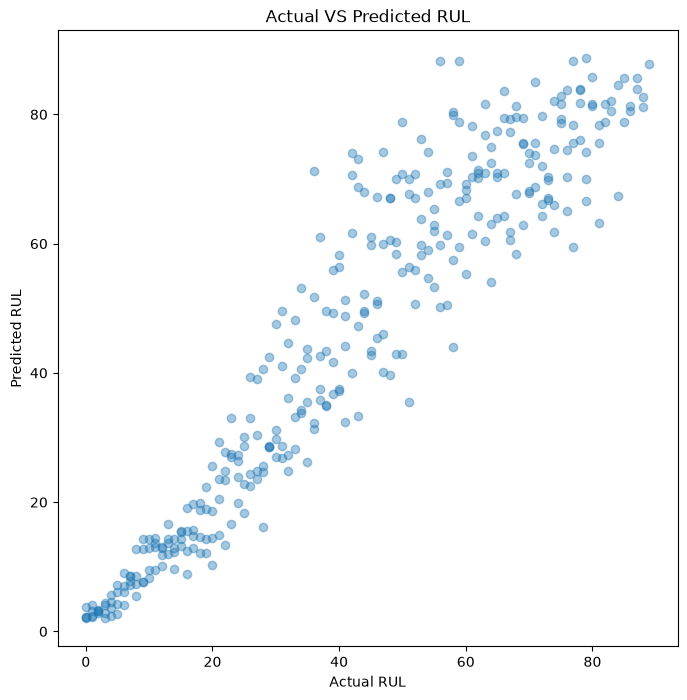

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.4)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual VS Predicted RUL")
plt.savefig("../docs/figs/Residual Plot - y test vs prediction.png", bbox_inches="tight")
plt.show()

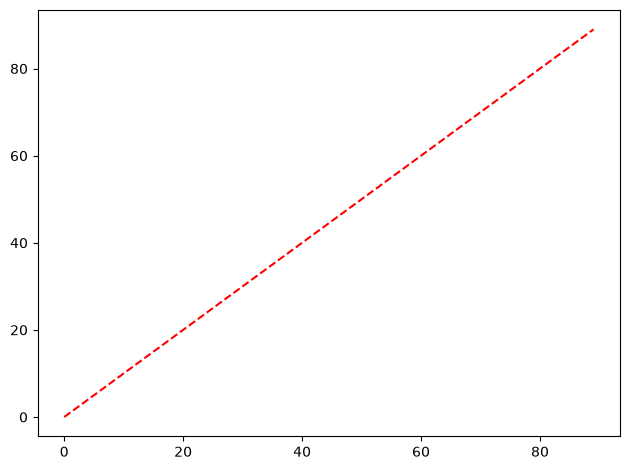

In [28]:
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")
plt.tight_layout()
plt.show()

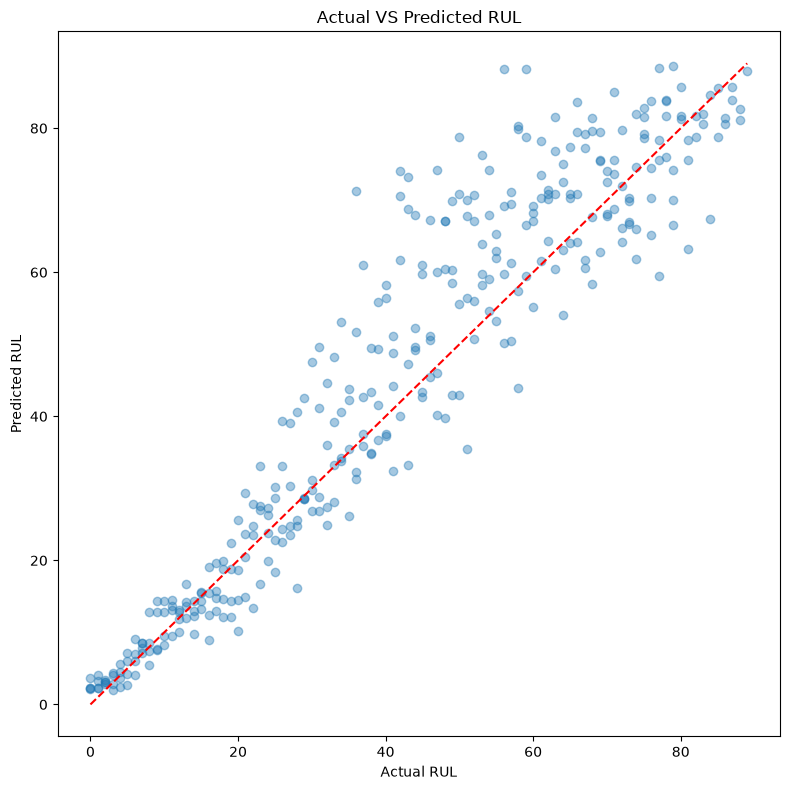

In [29]:
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.4)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual VS Predicted RUL")
plt.tight_layout()
plt.savefig("../docs/figs/perfect Predictions.png", bbox_inches="tight")
plt.show()

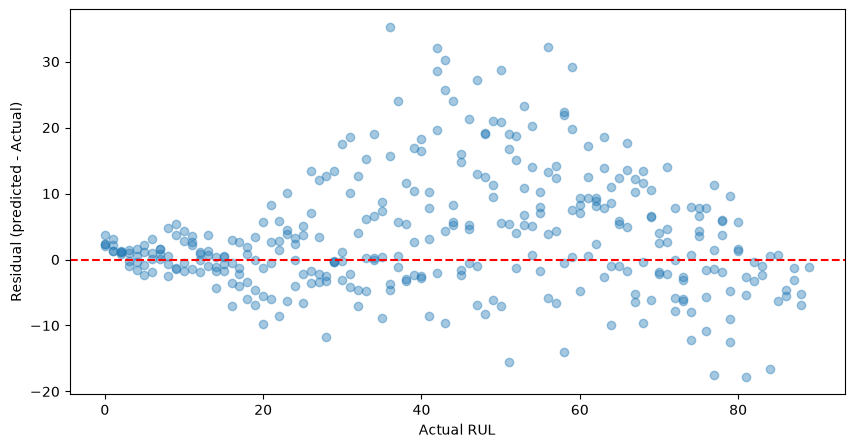

In [30]:
residual = predictions - y_test.values

plt.figure(figsize=(10, 5))
plt.scatter(y_test, residual, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual RUL")
plt.ylabel("Residual (predicted - Actual)")
plt.savefig("../docs/figs/Residual plt.png", bbox_inches="tight")
plt.show()

### Critical Zone Analysis

In [32]:
criticalZone_mask = y_test <= 20 

critical_rmse = np.sqrt(mean_squared_error(y_test[criticalZone_mask], predictions[criticalZone_mask]))
print("Critical Zone RMSE (RUL <= 20) : ", critical_rmse)
print("Number of Samples in critical Zone : ", criticalZone_mask.sum())

print("Overall Test RMSE : ", scores)

Critical Zone RMSE (RUL <= 20) :  2.8208758776868708
Number of Samples in critical Zone :  84
Overall Test RMSE :  9.523431091056088


## Final Test Set Evaluation

The Champion Model (XGBoost, `max_depth=2, learning_rate=0.1, n_estimators=200, subsample=0.7`) was retrained on **all 6 training units combined** and evaluated once on the independent, held-out `test_df.csv` (units never seen during training or LOUO-CV).

| Metric | LOUO-CV (train, avg across 6 folds) | **Held-out Test Set** |
|---|---|---|
| RMSE | 11.19 | **9.52** |
| PHM08 Score | ≈1035.45 (total) | **558.68** |

**Test performance matched or exceeded LOUO-CV estimates**, confirming the model generalizes well to genuinely unseen engines rather than overfitting to the training fleet.

⚠️ **Note:** The overall RMSE alone does not tell the full story — see [Error Analysis: Residuals & Critical Zone Performance](#error-analysis-residuals--critical-zone-performance) below, which shows the error is unevenly distributed and, importantly, at its lowest exactly where it matters most (near failure).

### Project Status: Modeling Phase Complete ✅

This concludes the core ML pipeline: EDA → Preprocessing (aggregation, residual correction, feature selection) → Baseline → Model comparison (Linear Regression, Random Forest, XGBoost) → Hyperparameter tuning → Final held-out test evaluation → Error analysis (residuals + critical zone).

**Next step:** Build a deployment layer (Streamlit interface / API) that surfaces predictions alongside an honest confidence caveat based on the error analysis findings — not raw predictions alone.

### Saving the model

In [33]:
import pickle as pk

with open("../models/XGBoost_finetuned.pkl", "wb") as f:
    pk.dump(model, f)